In [1]:
!pip install webdataset --quiet

# Experiment 02 - Deeper CNN

**Goal:** Does increasing depth increase baseline? 
**Model:** `DeepCNN`  
**Augmentation:** None (same as baseline -> isolates the effect of depth)  
**Comparison:** Macro-F1 vs Experiment 01 on the same test split

In [3]:
import sys, pathlib
ROOT = pathlib.Path('.').resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

import torch.nn as nn
from config import mount_drive, load_config
from augmentation import build_eval_transform
from dataset import build_dataloaders
from model import DeepCNN
from training import Trainer, compute_class_weights
from utils import set_seed, show_results, load_model, evaluate_model

mount_drive()
cfg = load_config(ROOT / 'content/configs/config.yaml')
set_seed(cfg.preprocessing.random_seed, cfg.device)

EXP_NAME = 'deep_cnn'
num_classes = len(cfg.classes)

eval_tf = build_eval_transform(cfg.preprocessing.image_size, use_imagenet_norm=False)

train_loader, val_loader, test_loader = build_dataloaders(
    train_transform=eval_tf,
    eval_transform=eval_tf,
    **cfg.dataloader_kwargs(),
)
print(f'Device: {cfg.device} | Dataset: {cfg.dataset_variant} | Train: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[config] environment: colab
  [DEBUG] _build_raw_loader: csv=/content/drive/MyDrive/asl/splits/asl_clean_mini/train.csv | num_workers=2 | pin_memory=True | OS=Linux
  [DEBUG] Dataset loaded: 370 samples
  [DEBUG] _build_raw_loader: csv=/content/drive/MyDrive/asl/splits/asl_clean_mini/val.csv | num_workers=2 | pin_memory=True | OS=Linux
  [DEBUG] Dataset loaded: 365 samples
  [DEBUG] _build_raw_loader: csv=/content/drive/MyDrive/asl/splits/asl_clean_mini/test.csv | num_workers=2 | pin_memory=True | OS=Linux
  [DEBUG] Dataset loaded: 356 samples
Device: cuda | Dataset: mini | Train: 2  Val: 3  Test: 3


DeepCNN - Trainable params: 1,446,757

  Experiment: deep_cnn
  Device: cuda  |  AMP: True  |  Epochs: 30


Epoch 001/30  train_loss=3.6168  train_acc=0.0156  val_loss=3.6105  val_acc=0.0274  val_F1=0.0015  [404.3s]
  New best val macro-F1=0.0015 - checkpoint saved


Epoch 002/30  train_loss=3.6049  train_acc=0.0312  val_loss=3.6045  val_acc=0.0219  val_F1=0.0121  [54.1s]
  New best val macro-F1=0.0121 - checkpoint saved


Epoch 003/30  train_loss=3.5723  train_acc=0.0469  val_loss=3.5956  val_acc=0.0274  val_F1=0.0031  [15.3s]


Epoch 004/30  train_loss=3.4914  train_acc=0.0352  val_loss=3.5946  val_acc=0.0438  val_F1=0.0220  [9.3s]
  New best val macro-F1=0.0220 - checkpoint saved


...

Epoch 026/30  train_loss=1.6012  train_acc=0.5469  val_loss=3.9662  val_acc=0.2274  val_F1=0.2330  [5.0s]


Epoch 027/30  train_loss=1.5916  train_acc=0.5547  val_loss=3.9797  val_acc=0.2219  val_F1=0.2285  [3.9s]


Epoch 028/30  train_loss=1.5051  train_acc=0.5820  val_loss=3.9907  val_acc=0.2219  val_F1=0.2285  [3.9s]


Epoch 029/30  train_loss=1.4538  train_acc=0.6133  val_loss=3.9954  val_acc=0.2137  val_F1=0.2197  [4.9s]


Epoch 030/30  train_loss=1.5572  train_acc=0.5430  val_loss=3.9966  val_acc=0.2137  val_F1=0.2197  [4.4s]


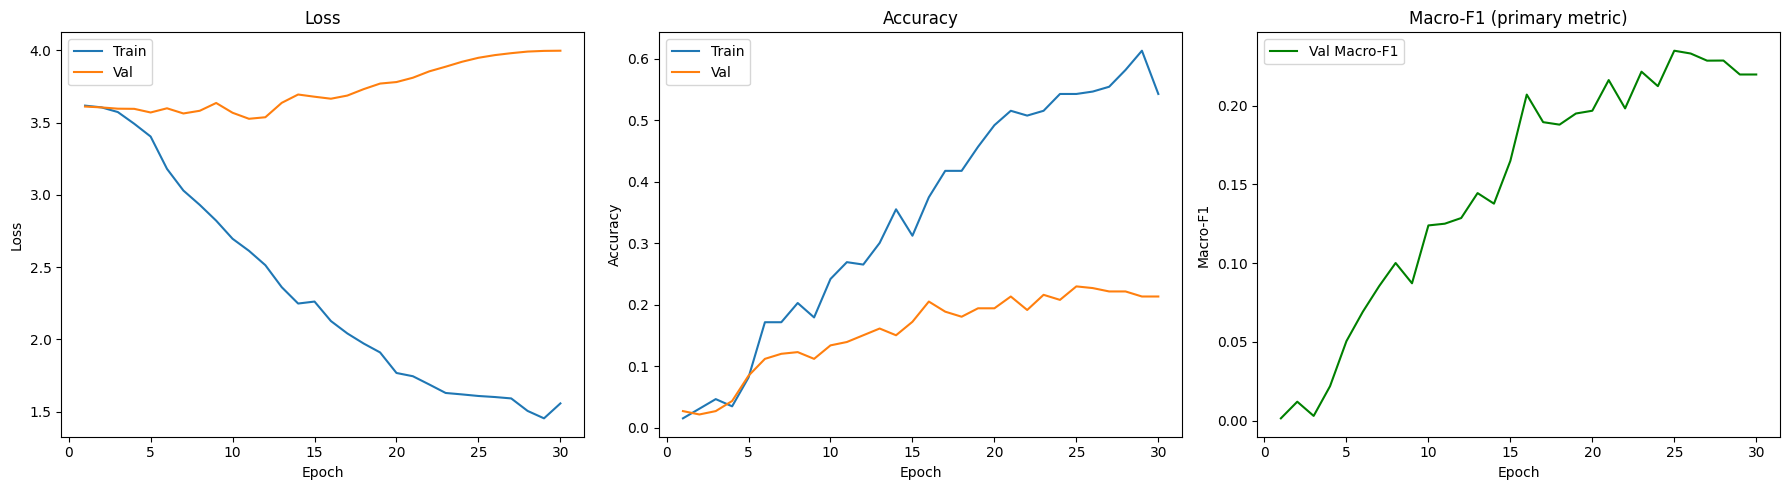

In [4]:
model = DeepCNN(in_channels=3, num_classes=num_classes)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DeepCNN - Trainable params: {n_params:,}')

class_weights = compute_class_weights(cfg.class_weight_source, num_classes) if cfg.training.use_class_weights else None

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=cfg.device,
    exp_name=EXP_NAME,
    results_root=cfg.results_root,
    checkpoints_root=cfg.checkpoints_root,
    num_epochs=cfg.training.num_epochs,
    learning_rate=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
    grad_clip=cfg.training.grad_clip,
    grad_accum_steps=cfg.training.grad_accum_steps,
    early_stopping_patience=cfg.training.early_stopping_patience,
    use_amp=cfg.training.use_amp,
    scheduler=cfg.training.scheduler,
    class_weights=class_weights,
    num_classes=num_classes,
)
history = trainer.train()

Test Macro-F1: 0.1693   Balanced Acc: 0.1773


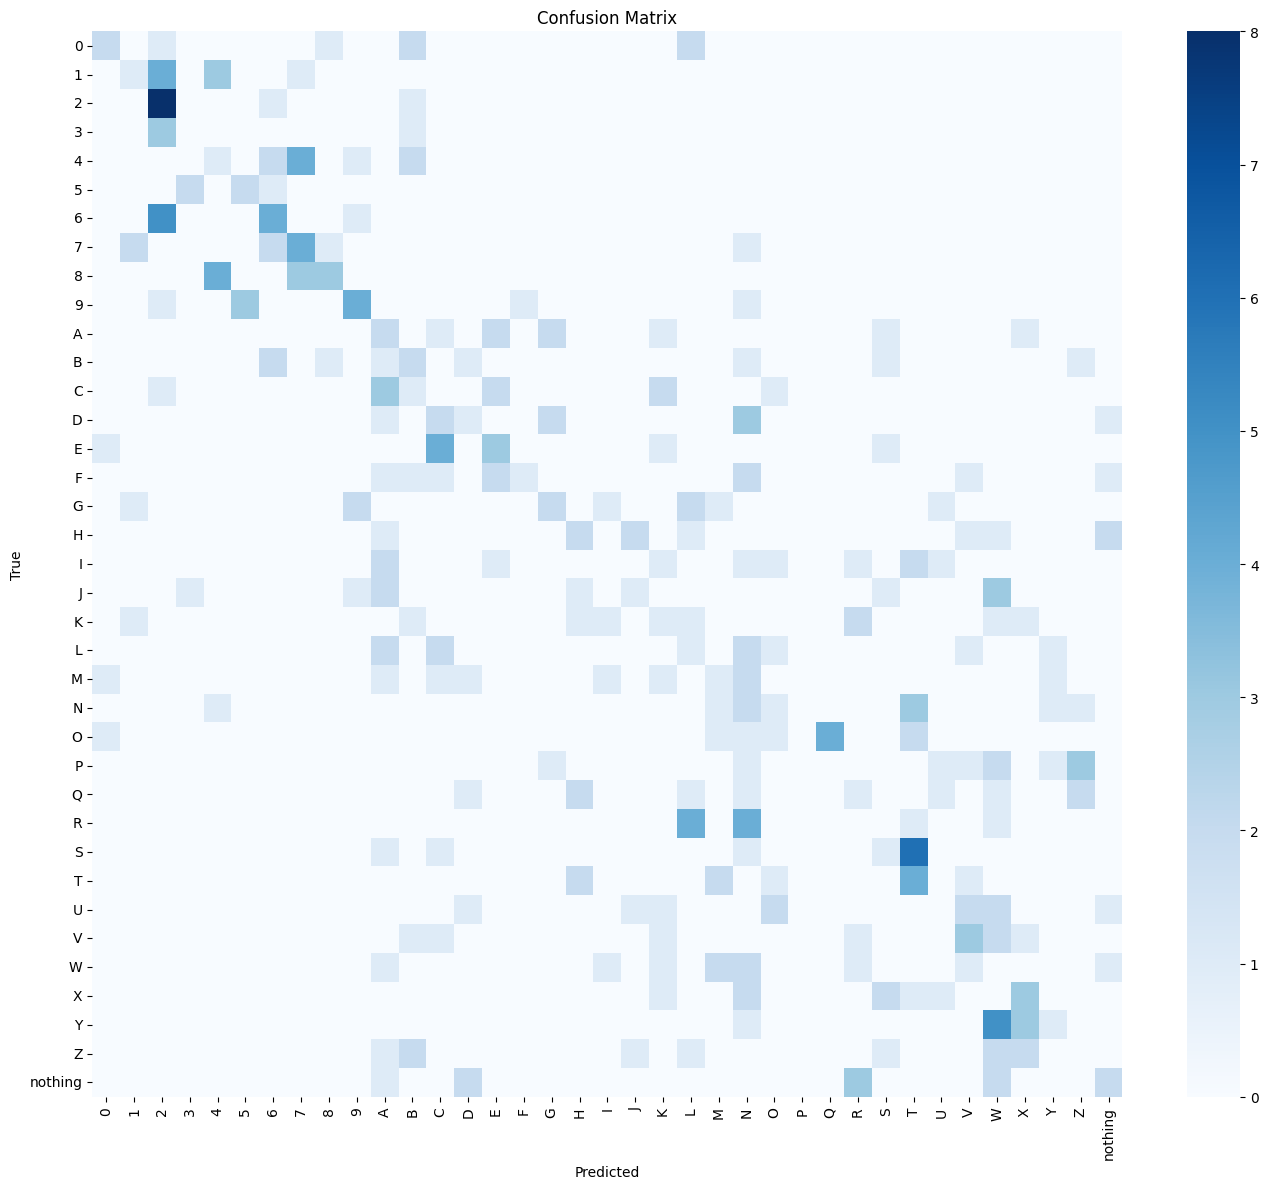

Macro-F1: 0.1693   Balanced Acc: 0.1773

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.25      0.31         8
           1       0.20      0.11      0.14         9
           2       0.35      0.80      0.48        10
           3       0.00      0.00      0.00         4
           4       0.11      0.10      0.11        10
           5       0.40      0.40      0.40         5
           6       0.33      0.40      0.36        10
           7       0.33      0.40      0.36        10
           8       0.50      0.30      0.38        10
           9       0.44      0.40      0.42        10
           A       0.10      0.20      0.13        10
           B       0.14      0.20      0.17        10
           C       0.00      0.00      0.00        10
           D       0.14      0.10      0.12        10
           E       0.30      0.30      0.30        10
           F       0.50      0.10      0.17        10
           G     

In [5]:
best_ckpt = cfg.checkpoints_root / EXP_NAME / 'best.pt'
model = load_model(DeepCNN(in_channels=3, num_classes=num_classes), str(best_ckpt), cfg.device)
_, _, test_f1, test_bal, true_labels, pred_labels = evaluate_model(
    model, test_loader, cfg.device, nn.CrossEntropyLoss()
)
print(f'Test Macro-F1: {test_f1:.4f}   Balanced Acc: {test_bal:.4f}')
show_results(true_labels, pred_labels, cfg.classes, save_dir=str(cfg.results_root / EXP_NAME))